<a href="https://colab.research.google.com/github/Zainab-Aijaz/Data-Science-project/blob/main/Copy_of_Churn_Customer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description

RowNumber: The sequential number assigned to each row in the dataset.

CustomerId: A unique identifier for each customer.

Surname: The surname of the customer.

CreditScore: The credit score of the customer.

Geography: The geographical location of the customer (e.g., country or region).

Gender: The gender of the customer.

Age: The age of the customer.

Tenure: The number of years the customer has been with the bank.

Balance: The account balance of the customer.

NumOfProducts: The number of bank products the customer has.

HasCrCard: Indicates whether the customer has a credit card (binary: yes/no).

IsActiveMember: Indicates whether the customer is an active member (binary: yes/no).

EstimatedSalary: The estimated salary of the customer.

Exited: Indicates whether the customer has exited the bank (binary: yes/no).

A customer churn dataset is typically used to analyze why customers stop using a company's service (known as "churn") and to predict future churn based on historical data. In this type of dataset, each row represents a unique customer, and the columns contain attributes related to customer demographics, account details, and usage metrics

In [ ]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler ,LabelEncoder
from sklearn.model_selection import train_test_split ,GridSearchCV ,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
df= pd.read_csv("/content/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
# standardize Colunm name
df.columns=(
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')

)
df

,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
#remove Duplicate Rows
df.drop_duplicates(inplace=True)

In [ ]:
df =df.drop(['rownumber','customerid','surname'],axis=1)
df.head()

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Example
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 18, 30, 45, 60, 100],
                         labels=['0-18', '18-30', '30-45', '45-60', '60+'])

/tmp/ipykernel_1898/1010582154.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['balance'], x=df['gender'],palette='viridis')


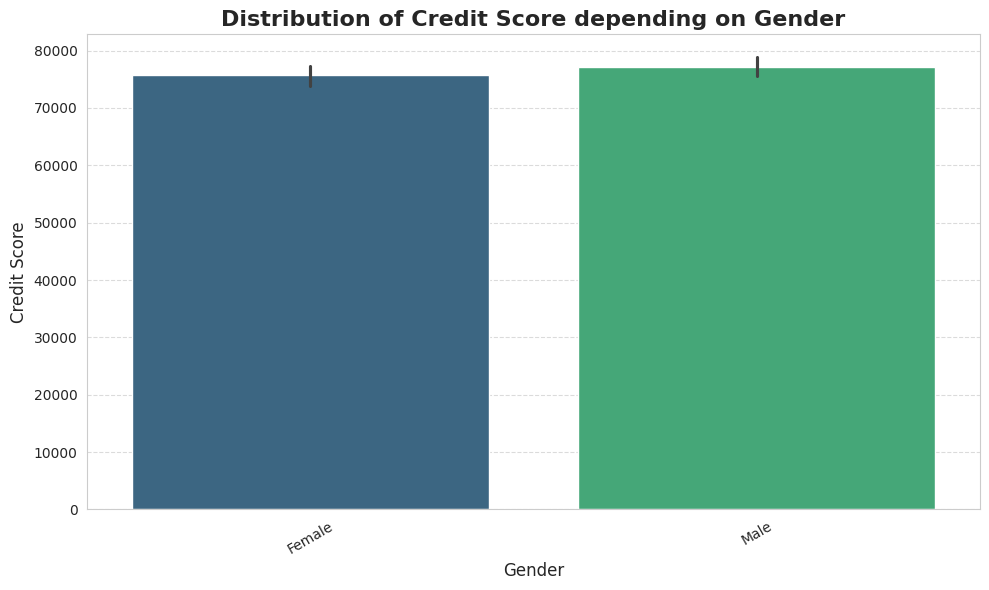

In [ ]:

# Style
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

# Your same plot
sns.barplot(y=df['balance'], x=df['gender'],palette='viridis')

# Beautification
plt.title('Distribution of Credit Score depending on Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1898/1548866294.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['exited'], x=df['geography'],palette='viridis')


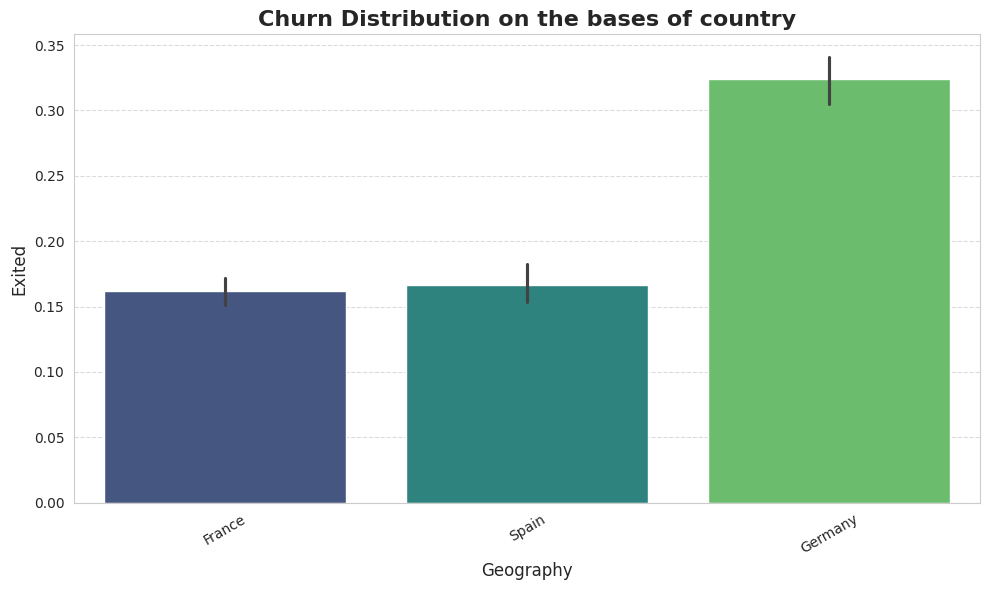

In [ ]:

# Style
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

# Your same plot
sns.barplot(y=df['exited'], x=df['geography'],palette='viridis')

# Beautification
plt.title('Churn Distribution on the bases of country', fontsize=16, fontweight='bold')
plt.xlabel('Geography', fontsize=12)
plt.ylabel('Exited', fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<Axes: xlabel='tenure'>

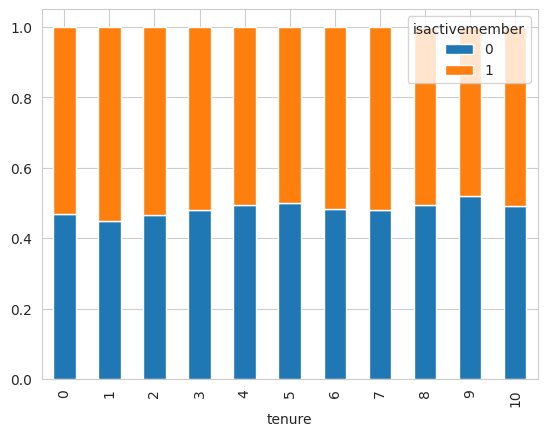

In [ ]:
ct = pd.crosstab(df['tenure'], df['isactivemember'], normalize='index')

ct.plot(kind='bar', stacked=True)

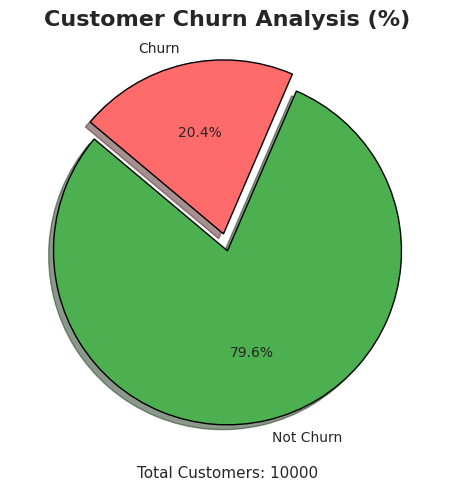

In [ ]:
import matplotlib.pyplot as plt

# Data
churn_counts = df['exited'].value_counts()

# Labels
labels = ['Not Churn', 'Churn']

# Colors (professional palette)
colors = ['#4CAF50', '#FF6B6B']   # green = retained, red = churn

plt.figure(figsize=(5,5))

plt.pie(churn_counts,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=140,
        explode=(0, 0.1),   # highlight churn
        shadow=True,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})

# Title
plt.title('Customer Churn Analysis (%)',
          fontsize=16,
          fontweight='bold')

# Annotation (extra insight)
plt.text(0, -1.3,
         f'Total Customers: {len(df)}',
         ha='center',
         fontsize=11)

plt.tight_layout()
plt.show()


In [ ]:
df['isactivemember'].corr(df['exited'])

np.float64(-0.15612827818890512)

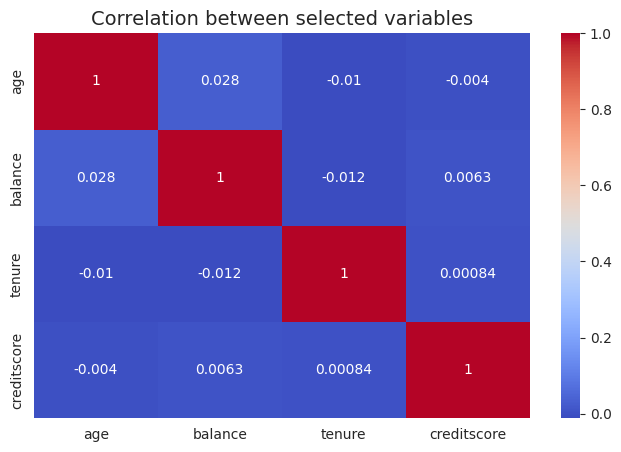

In [ ]:
cols = ['age', 'balance', 'tenure', 'creditscore']
corr_matrix = df[cols].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Correlation between selected variables', fontsize=14)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('exited', axis=1)
y = df['exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df.getdummies

In [ ]:
# First, apply one-hot encoding to the categorical columns in X_train and X_test
X_train = pd.get_dummies(X_train, columns=['geography', 'gender', 'age_group'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['geography', 'gender', 'age_group'], drop_first=True)

# Then, apply StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8355
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1607
           1       0.68      0.31      0.43       393

    accuracy                           0.84      2000
   macro avg       0.76      0.64      0.66      2000
weighted avg       0.82      0.84      0.81      2000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Logistic Regression Accuracy: 0.8355
Random Forest Accuracy: 0.867
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,                # 3-fold cross validation
    scoring='recall',    # IMPORTANT for medical data
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [ ]:
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8625
[[1545   62]
 [ 213  180]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.46      0.57       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



After hyperparameter tuning, the model shows improved performance, particularly in recall for the churn class. However, due to class imbalance, a significant number of churn customers are still misclassified. Further improvement requires resampling techniques or cost-sensitive learning.”